Generating multiclass data...
Data shape: (1000, 2)
Number of classes: 5

Creating models...
Single layer model parameters: 15
Multi layer model parameters: 305

Training single layer model...
Epoch [100/1000], Loss: 1.0050, Accuracy: 0.5030
Epoch [200/1000], Loss: 0.6815, Accuracy: 0.9750
Epoch [300/1000], Loss: 0.4997, Accuracy: 0.9950
Epoch [400/1000], Loss: 0.3911, Accuracy: 1.0000
Epoch [500/1000], Loss: 0.3209, Accuracy: 1.0000
Epoch [600/1000], Loss: 0.2723, Accuracy: 1.0000
Epoch [700/1000], Loss: 0.2369, Accuracy: 1.0000
Epoch [800/1000], Loss: 0.2099, Accuracy: 1.0000
Epoch [900/1000], Loss: 0.1887, Accuracy: 1.0000
Epoch [1000/1000], Loss: 0.1717, Accuracy: 1.0000

Training multi layer model...
Epoch [100/1000], Loss: 1.2190, Accuracy: 0.9950
Epoch [200/1000], Loss: 0.7495, Accuracy: 0.9960
Epoch [300/1000], Loss: 0.3206, Accuracy: 0.9990
Epoch [400/1000], Loss: 0.1297, Accuracy: 0.9990
Epoch [500/1000], Loss: 0.0676, Accuracy: 0.9990
Epoch [600/1000], Loss: 0.0437, Accuracy

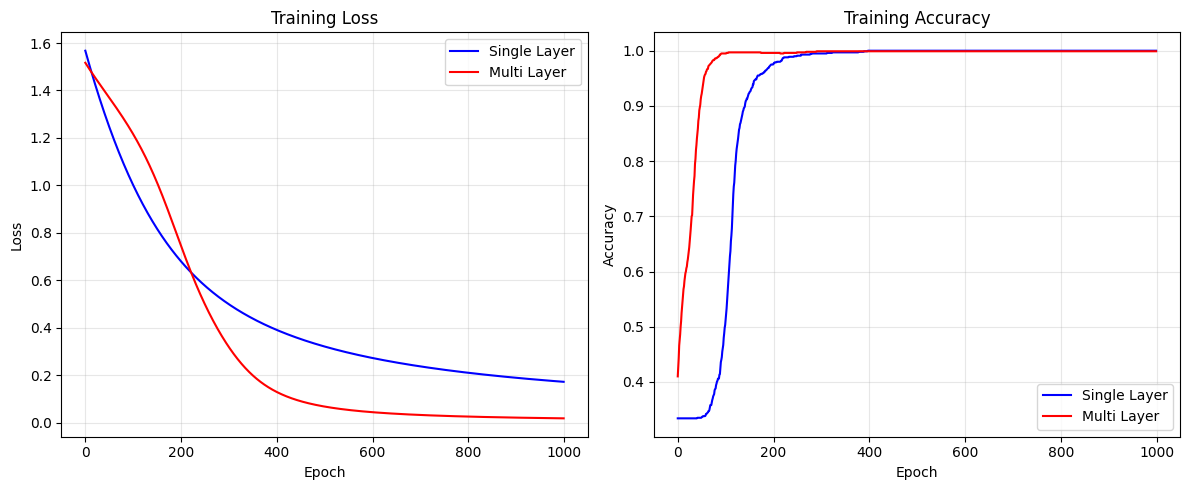

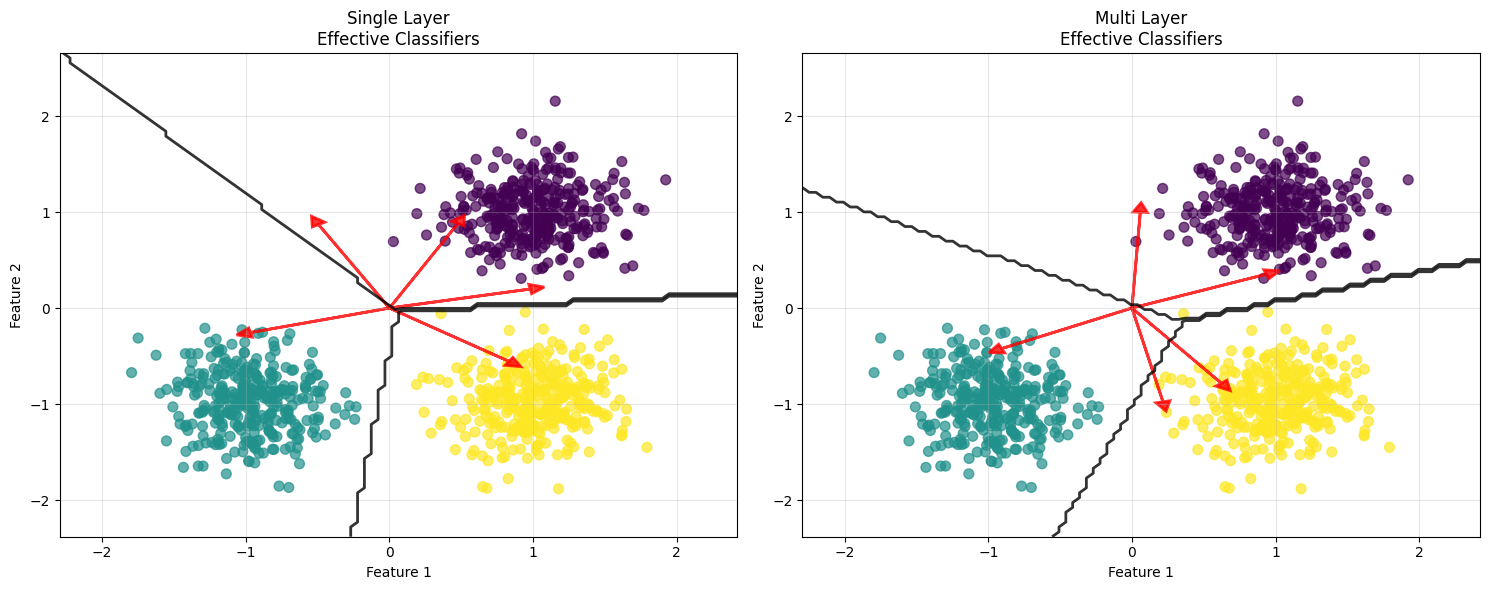

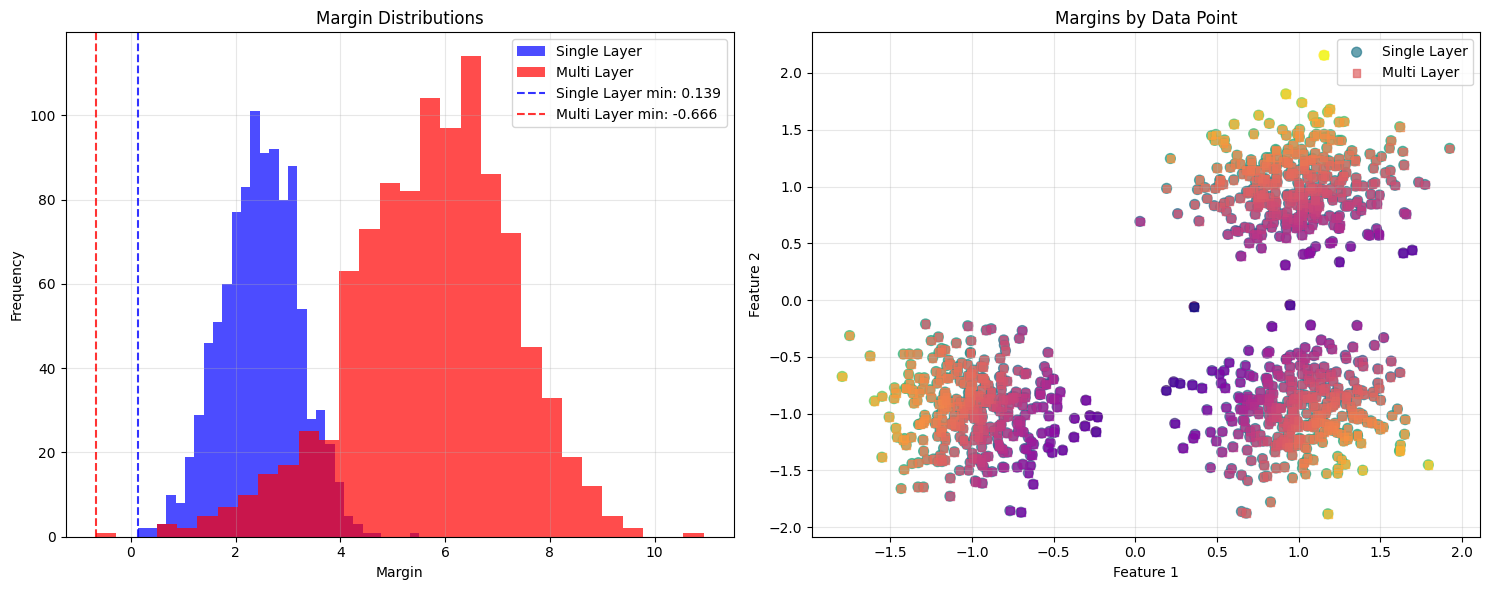


Final Statistics:
Single Layer - Final Accuracy: 1.0000, Min Margin: 0.1387
Multi Layer - Final Accuracy: 0.9990, Min Margin: -0.6664

Effective Weight Matrix Norms:
Single Layer: 3.1074
Multi Layer: 7.8950


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import seaborn as sns

class SingleLayerNetwork(nn.Module):
    """Single layer linear network (no hidden layers)"""
    def __init__(self, input_dim, num_classes):
        super(SingleLayerNetwork, self).__init__()
        self.linear = nn.Linear(input_dim, num_classes)
        
    def forward(self, x):
        return self.linear(x)

class MultiLayerNetwork(nn.Module):
    """Linear network with L hidden layers"""
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers):
        super(MultiLayerNetwork, self).__init__()
        self.num_layers = num_layers
        
        # Create layers
        layers = []
        prev_dim = input_dim
        
        for i in range(num_layers):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            prev_dim = hidden_dim
            
        # Output layer
        layers.append(nn.Linear(prev_dim, num_classes))
        
        self.layers = nn.ModuleList(layers)
        
    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
        return self.layers[-1](x)
    
    def get_effective_weights(self):
        """Compute the effective weight matrix (W_eff = W_L * W_{L-1} * ... * W_1)"""
        effective_W = self.layers[0].weight
        for layer in self.layers[1:]:
            effective_W = torch.mm(layer.weight, effective_W)
        return effective_W

def generate_multiclass_data(n_samples=1000, n_classes=3, n_features=2, random_state=42):
    """Generate linearly separable multiclass data"""
    np.random.seed(random_state)
    
    # Generate blobs for each class
    centers = np.array([[1, 1], [-1, -1], [1, -1]])[:n_classes]
    X, y = make_blobs(n_samples=n_samples, centers=centers, 
                      cluster_std=0.3, random_state=random_state)
    
    # Convert to one-hot encoding
    y_onehot = np.zeros((len(y), n_classes))
    y_onehot[np.arange(len(y)), y] = 1
    
    return X, y, y_onehot

def compute_margins(model, X, y_onehot):
    """Compute the minimum margin for each sample"""
    model.eval()
    with torch.no_grad():
        logits = model(X)
        margins = []
        
        for i in range(len(X)):
            sample_logits = logits[i]
            true_class = torch.argmax(y_onehot[i])
            true_score = sample_logits[true_class]
            
            # Get scores for other classes
            other_scores = torch.cat([sample_logits[:true_class], sample_logits[true_class+1:]])
            max_other_score = torch.max(other_scores)
            
            margin = true_score - max_other_score
            margins.append(margin.item())
    
    return np.array(margins)

def train_model(model, X, y_onehot, learning_rate=0.01, num_epochs=1000, verbose=True):
    """Train a model on the given data"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    
    losses = []
    accuracies = []
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        
        outputs = model(X)
        loss = criterion(outputs, y_onehot)
        
        loss.backward()
        optimizer.step()
        
        # Compute accuracy
        _, predicted = torch.max(outputs, 1)
        _, true_labels = torch.max(y_onehot, 1)
        accuracy = (predicted == true_labels).float().mean().item()
        
        losses.append(loss.item())
        accuracies.append(accuracy)
        
        if verbose and (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}')
    
    return losses, accuracies

def plot_decision_boundaries(X, y, model1, model2, model1_name="Single Layer", model2_name="Multi Layer"):
    """Plot the data and decision boundaries for both models"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Create meshgrid for decision boundaries
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    models = [model1, model2]
    names = [model1_name, model2_name]
    
    for idx, (model, name) in enumerate(zip(models, names)):
        ax = axes[idx]
        
        # Get effective weights
        if isinstance(model, SingleLayerNetwork):
            effective_W = model.linear.weight.detach().numpy()
        else:
            effective_W = model.get_effective_weights().detach().numpy()
        
        # Plot decision boundaries
        Z = np.zeros(xx.shape)
        for i in range(xx.shape[0]):
            for j in range(xx.shape[1]):
                point = np.array([[xx[i, j], yy[i, j]]])
                point_tensor = torch.FloatTensor(point)
                with torch.no_grad():
                    logits = model(point_tensor)
                    Z[i, j] = torch.argmax(logits).item()
        
        # Plot data points
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7, s=50)
        
        # Plot decision boundaries
        ax.contour(xx, yy, Z, levels=np.arange(-0.5, len(np.unique(y)) + 0.5), 
                  colors='black', linewidths=2, alpha=0.8)
        
        # Plot effective classifiers (normal vectors to decision boundaries)
        for i in range(effective_W.shape[0]):
            w = effective_W[i]
            # Normalize the weight vector
            w_norm = w / np.linalg.norm(w)
            # Plot the normal vector from origin
            ax.arrow(0, 0, w_norm[0], w_norm[1], head_width=0.1, head_length=0.1, 
                    fc='red', ec='red', alpha=0.8, linewidth=2)
        
        ax.set_title(f'{name}\nEffective Classifiers')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_margins_comparison(X, y, margins1, margins2, model1_name="Single Layer", model2_name="Multi Layer"):
    """Plot margin distributions for both models"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot margin distributions
    axes[0].hist(margins1, bins=30, alpha=0.7, label=model1_name, color='blue')
    axes[0].hist(margins2, bins=30, alpha=0.7, label=model2_name, color='red')
    axes[0].axvline(np.min(margins1), color='blue', linestyle='--', alpha=0.8, 
                    label=f'{model1_name} min: {np.min(margins1):.3f}')
    axes[0].axvline(np.min(margins2), color='red', linestyle='--', alpha=0.8,
                    label=f'{model2_name} min: {np.min(margins2):.3f}')
    axes[0].set_xlabel('Margin')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Margin Distributions')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot margins vs data points
    axes[1].scatter(X[:, 0], X[:, 1], c=margins1, cmap='viridis', alpha=0.7, s=50, 
                    label=model1_name, marker='o')
    axes[1].scatter(X[:, 0], X[:, 1], c=margins2, cmap='plasma', alpha=0.7, s=30, 
                    label=model2_name, marker='s')
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    axes[1].set_title('Margins by Data Point')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Parameters
n_samples = 1000
n_classes = 5
n_features = 2
hidden_dim = 10
num_layers = 3
learning_rate = 0.01
num_epochs = 1000

print("Generating multiclass data...")
X, y, y_onehot = generate_multiclass_data(n_samples, n_classes, n_features)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X)
y_onehot_tensor = torch.FloatTensor(y_onehot)

print(f"Data shape: {X.shape}")
print(f"Number of classes: {n_classes}")

# Create models
print("\nCreating models...")
single_layer_model = SingleLayerNetwork(n_features, n_classes)
multi_layer_model = MultiLayerNetwork(n_features, hidden_dim, n_classes, num_layers)

print(f"Single layer model parameters: {sum(p.numel() for p in single_layer_model.parameters())}")
print(f"Multi layer model parameters: {sum(p.numel() for p in multi_layer_model.parameters())}")

# Train models
print("\nTraining single layer model...")
losses1, accuracies1 = train_model(single_layer_model, X_tensor, y_onehot_tensor, 
                                    learning_rate, num_epochs)

print("\nTraining multi layer model...")
losses2, accuracies2 = train_model(multi_layer_model, X_tensor, y_onehot_tensor, 
                                    learning_rate, num_epochs)

# Compute margins
print("\nComputing margins...")
margins1 = compute_margins(single_layer_model, X_tensor, y_onehot_tensor)
margins2 = compute_margins(multi_layer_model, X_tensor, y_onehot_tensor)

print(f"Single layer - Min margin: {np.min(margins1):.4f}, Mean margin: {np.mean(margins1):.4f}")
print(f"Multi layer - Min margin: {np.min(margins2):.4f}, Mean margin: {np.mean(margins2):.4f}")

# Plot results
print("\nPlotting results...")

# Plot training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses1, label='Single Layer', color='blue')
plt.plot(losses2, label='Multi Layer', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(accuracies1, label='Single Layer', color='blue')
plt.plot(accuracies2, label='Multi Layer', color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot decision boundaries and effective classifiers
plot_decision_boundaries(X, y, single_layer_model, multi_layer_model)

# Plot margin comparisons
plot_margins_comparison(X, y, margins1, margins2)

# Print final statistics
print("\nFinal Statistics:")
print(f"Single Layer - Final Accuracy: {accuracies1[-1]:.4f}, Min Margin: {np.min(margins1):.4f}")
print(f"Multi Layer - Final Accuracy: {accuracies2[-1]:.4f}, Min Margin: {np.min(margins2):.4f}")

# Compare effective weights
single_W = single_layer_model.linear.weight.detach().numpy()
multi_W = multi_layer_model.get_effective_weights().detach().numpy()

print(f"\nEffective Weight Matrix Norms:")
print(f"Single Layer: {np.linalg.norm(single_W):.4f}")
print(f"Multi Layer: {np.linalg.norm(multi_W):.4f}")
